In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

D:\Promotion\neurolib\GUI\current\gui\data\00001
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [33]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

file found


In [10]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  52 0.5500000000000003 0.5750000000000003
-------  104 0.4250000000000001 0.7750000000000005


In [11]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  52 0.5500000000000003 0.5750000000000003
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30191.234275043676
Gradient descend method:  None
RUN  0 , total integrated cost =  30191.234275043676
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6120.770160604903
Gradient descend method:  None
RUN  0 , total integrated cost =  6120.770160604903
Improved over  0  iterations in  0.0  seconds by  0.0  percent.


In [12]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  52 104]


In [13]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1490.90120276401
RUN  2 , total integrated cost =  563.3710174516267
RUN  3 , total integrated cost =  392.29675633594616
RUN  4 , total integrated cost =  281.2699702301244
RUN  5 , total integrated cost =  213.09753825752765
RUN  6 , total integrated cost =  167.9131810901443
RUN  7 , total integrated cost =  135.57498895138446
RUN  8 , total integrated cost =  114.53668475632618
RUN  9 , total integrated cost =  97.86304731913953
RUN  10 , total integrated cost =  84.61241602745966
RUN  11 , total integrated cost =  74.29278873885022
RUN  12 , total integrated cost =  66.1419244244457
RUN  13 , total integrated cost =  59.490248822947585
RUN  14 , total integrated cost =  54.19478375929194
RUN  15 , total integrated cost =  49.825068554568084
RUN  16 ,

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  1208 , total integrated cost =  5277.542799254231
Improved over  1208  iterations in  414.9412105  seconds by  10.53817205891751  percent.
Problem in initial value trasfer:  Vmean_exc -56.62741921506069 -56.627420078118405
-------  52 0.5500000000000003 0.5750000000000003
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30191.234275043676
Gradient descend method:  None
RUN  1 , total integrated cost =  1895.6611238410728
RUN  2 , total integrated cost =  1534.6834546307448
RUN  3 , total integrated cost =  129.45301010331795
RUN  4 , total integrated cost =  65.98560867044134
RUN  5 , total integrated cost =  54.809865947850184
RUN  6 , total integrated cost =  50.821266772732876
RUN  7 , total integrated cost =  48.85191401731748
RUN  8 , total integrated cost =  47.70366784715288
RUN  9 , total integrated cost =  46.92451104465942
RUN  10 , total integrated cost =  46.36691435334473
RUN  11 , 

[ 0.00000000e+00 -1.31595069e-13 -1.59037109e-12 -1.41563188e-11
 -1.01340808e-10 -5.62310826e-10 -1.77829083e-09  8.61315196e-09
  2.23320276e-07  2.56863928e-06  2.22292626e-05  1.54916701e-04
  8.23954034e-04  2.16591418e-03 -8.73888830e-03  4.03168190e-02
  5.20571744e-03]
[0.00000000e+00 1.70060079e-13 1.56987879e-12 1.44920515e-11
 1.33780747e-10 1.23497272e-09 1.14004268e-08 1.05240975e-07
 9.71513139e-07 8.96836034e-06 8.27908909e-05 7.64362695e-04
 7.06406650e-03 6.39999793e-02 2.12459051e-01 1.32401591e-02
 8.34308139e-05]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


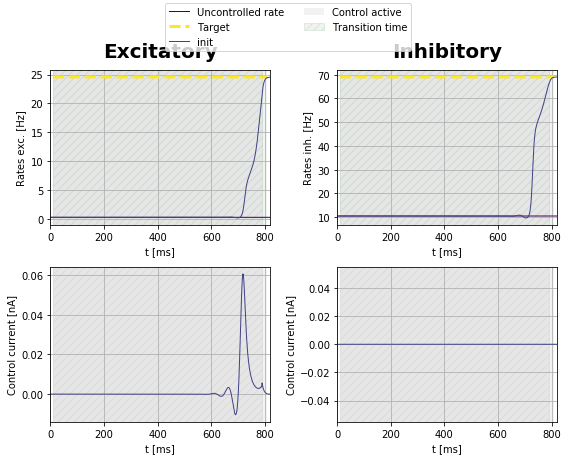

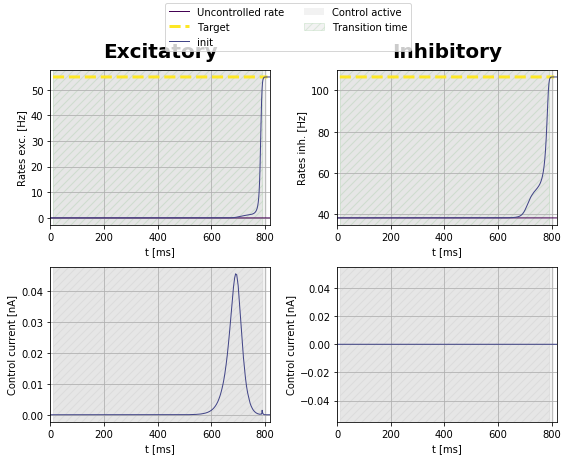

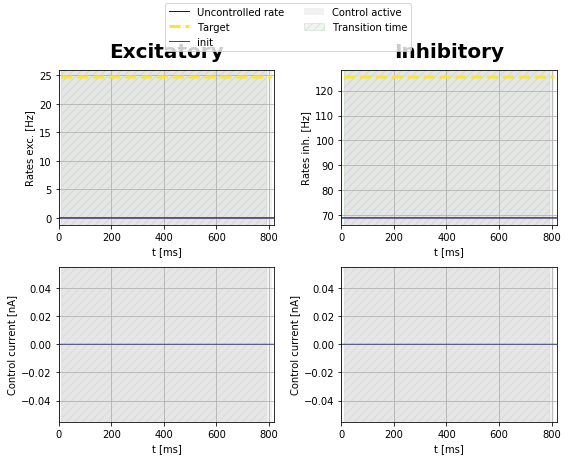

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [46]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001


TypeError: 'NoneType' object is not subscriptable

In [16]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4557.876123278912
set cost params:  1.0 0.0 4557.876123278912
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5899.214289182648
Gradient descend method:  None
RUN  1 , total integrated cost =  5899.169404651368
RUN  2 , total integrated cost =  5899.168291629906
RUN  3 , total integrated cost =  5899.168148707322
RUN  4 , total integrated cost =  5899.168111080613
RUN  5 , total integrated cost =  5899.168095237879
RUN  6 , total integrated cost =  5899.168087006306
RUN  7 , total integrated cost =  5899.168081970155
RUN  8 , total integrated cost =  5899.168078290464
RUN  9 , total integrated cost =  5899.16807584879
RUN  10 , total integrated cost =  5899.168074080459
RUN  11 , total integrated cost =  5899.168072607835
RUN  12 , total integrated cost =  5899.16807130947
RUN  13 , total integ

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  77 , total integrated cost =  5888.888418383365
Improved over  77  iterations in  6.465208000000075  seconds by  0.17503806936150568  percent.
Problem in initial value trasfer:  Vmean_exc -56.62727964462869 -56.62728111795316
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6244.305612866145
set cost params:  1.0 0.0 6244.305612866145
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.29247346209
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.28451996091
RUN  2 , total integrated cost =  17065.284072900256
RUN  3 , total integrated cost =  17065.28398828102
RUN  4 , total integrated cost =  17065.2839324275
RUN  5 , total integrated cost =  17065.28385589153
RUN  6 , total integrated cost =  17065.283797474694
RUN  7 , total integrated cost =  17065.283743360695
RUN  8 , total integrated cost =  17065.28364877366
RUN  9 , total integrated cost =  17065.28340858995
RUN  10

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  44 , total integrated cost =  17064.682694684696
Improved over  44  iterations in  3.575935600000321  seconds by  0.0035732102355865436  percent.
Problem in initial value trasfer:  Vmean_exc -56.68751501509493 -56.687515155075644
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  20953.48425340365
set cost params:  1.0 0.0 20953.48425340365
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30189.509669893985
Gradient descend method:  None
RUN  1 , total integrated cost =  30189.5074947258
RUN  2 , total integrated cost =  30189.50747017886
RUN  3 , total integrated cost =  30189.507469582517
RUN  4 , total integrated cost =  30189.50746956812
RUN  5 , total integrated cost =  30189.507469567547
RUN  6 , total integrated cost =  30189.507469567532
RUN  7 , total integrated cost =  30189.50746956752
RUN  8 , total integrated cost =  30189.507469567518
RUN  9 , total integrated cost =  30189.507469567514
R

...

Control only changes marginally.
RUN  1 , total integrated cost =  24570.997141958756
Improved over  1  iterations in  0.17595239999991463  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70192145090937 -56.70192146580085
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
[[False, False], [False, False], [False, False], [False, False], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  4567.385021359926
set cost params:  1.0 0.0 4567.385021359926
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.114176120224
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.114176120025
RUN  2 , total integrated cost =  5901.114176119825
RUN  3 , total integrated cost =  5901.114176119342
RUN  4 , total integrated cost =  5901.1141761190875
RUN  5 , total integrated cost =  5901.114176118952

ERROR:root:Problem in initial value trasfer


RUN  12 , total integrated cost =  5901.114176118785
Control only changes marginally.
RUN  12 , total integrated cost =  5901.114176118785
Improved over  12  iterations in  1.1205912000000353  seconds by  2.440003754600184e-11  percent.
Problem in initial value trasfer:  Vmean_exc -56.627278228396186 -56.627279716900304
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
no convergence
weight =  20953.682873470236
set cost params:  1.0 0.0 20953.682873470236
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  30189.79348798326
Gradient descend method:  None
RUN  1 , total integrated cost =  30189.79348798326
Control only changes marginally.
RUN  1 , total integrated cost =  30189.79348798326
Improved over  1  iterations in  0.18525590000035663  seconds by  0.0  percent.
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.114466269902
Control only changes marginally.
RUN  1 , total integrated cost =  5901.114466269902
Improved over  1  iterations in  0.1915062999996735  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627278228396186 -56.627279716900304
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
[[False, False], [True, True], [True, False], [True, True], [True, True], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  78 0.5250000000000001 0.6750000000000004
converged fo

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  72.21100749308248
Gradient descend method:  None
RUN  1 , total integrated cost =  17.164905679102855
RUN  2 , total integrated cost =  14.763890914529679
RUN  3 , total integrated cost =  14.088098802514683
RUN  4 , total integrated cost =  13.793047776983222
RUN  5 , total integrated cost =  13.74657592112014
RUN  6 , total integrated cost =  13.715579007358674
RUN  7 , total integrated cost =  13.69163519362158
RUN  8 , total integrated cost =  13.68303895189856
RUN  9 , total integrated cost =  13.674065767579009
RUN  10 , total integrated cost =  13.669058711273859
RUN  11 , total integrated cost =  13.662864638130127
RUN  12 , total integrated cost =  13.659088145449756
RUN  13 , total integrated cost =  13.65359814624192
RUN  14 , total integrated cost =  13.649583401663506
RUN  15 , total integrated cost =  13.64235128794319
RUN

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  789 , total integrated cost =  101.76935131128909
Improved over  789  iterations in  86.64934440000002  seconds by  22.98191812701417  percent.
Problem in initial value trasfer:  Vmean_exc -56.627599606367575 -56.62760007673349
weight =  5798.787856743114
set cost params:  1.0 0.0 5798.787856743114
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5889.095220446932
Gradient descend method:  None
RUN  1 , total integrated cost =  5787.429554682147
RUN  2 , total integrated cost =  5783.909688537014
RUN  3 , total integrated cost =  5779.402616178644
RUN  4 , total integrated cost =  5776.387985525821
RUN  5 , total integrated cost =  5764.588571802173
RUN  6 , total integrated cost =  5763.580193668789
RUN  7 , total integrated cost =  5761.501370051964
RUN  8 , total integrated cost =  5758.957056460672
RUN  9 , total integrated cost =  5756.881791332286
RUN  10 , total integrated cost =  5754.341857580221
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  127 , total integrated cost =  5567.256023581638
Improved over  127  iterations in  10.313036999999895  seconds by  5.465002429369264  percent.
Problem in initial value trasfer:  Vmean_exc -56.62679428245885 -56.626800514777706
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  49.60648279884865
Gradient descend method:  None
RUN  1 , total integrated cost =  3.8391061441790986
RUN  2 , total integrated cost =  3.803240285600791
RUN  3 , total integrated cost =  3.795342645674966
RUN  4 , total integrated cost =  3.7862807884447656
RUN  5 , total integrated cost =  3.783537767430689
RUN  6 , total integrated cost =  3.7831386535589777
RUN  7 , total integrated cost =  3.7824736271896735
RUN  8 , total integrated cost =  3.782127481536654
RUN  9 , total integrated cost =  3.77996582102634
RUN  10 , total integrated c

...

 9 , total integrated cost =  14534.291814313272
Control only changes marginally.
RUN  9 , total integrated cost =  14534.291814313272
Improved over  9  iterations in  1.59239209999987  seconds by  0.04383175134347539  percent.
Problem in initial value trasfer:  Vmean_exc -56.67722093440763 -56.67722300057472
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  71.7495374605896
Gradient descend method:  None
RUN  1 , total integrated cost =  12.578372820334712
RUN  2 , total integrated cost =  12.575002863011804
RUN  3 , total integrated cost =  12.562420037767708
RUN  4 , total integrated cost =  12.559454420138717
RUN  5 , total integrated cost =  12.554779582352703
RUN  6 , total integrated cost =  12.553025975403793
RUN  7 , total integrated cost =  12.552647832736241
RUN  8 , total integrated cost =  12.552047495299878
RUN  9 , total integrated cost =  12.551894885143735
RUN  10 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  89 , total integrated cost =  124.08749875049074
Improved over  89  iterations in  15.575149099999635  seconds by  0.4693496898127876  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027506093939 -56.7002750424957
weight =  31116.568138616618
set cost params:  1.0 0.0 31116.568138616618
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38601.65133144921
Gradient descend method:  None
RUN  1 , total integrated cost =  38484.72250409252
RUN  2 , total integrated cost =  38484.531936019695
RUN  3 , total integrated cost =  38484.52627458286
RUN  4 , total integrated cost =  38484.52431828794
RUN  5 , total integrated cost =  38484.52323096132
RUN  6 , total integrated cost =  38484.52013312202
RUN  7 , total integrated cost =  38484.50994106809
RUN  8 , total integrated cost =  38483.54672731664
RUN  9 , total integrated cost =  38481.84026434516
RUN  10 , total integrated cost =  38481.79467813767
RUN  11 , total int

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  46 , total integrated cost =  38471.12568841712
Improved over  46  iterations in  8.873633400000017  seconds by  0.33813486866492326  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027556795196 -56.70027552632313


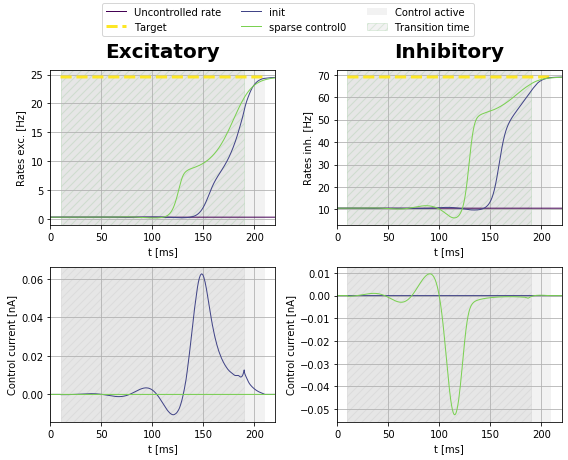

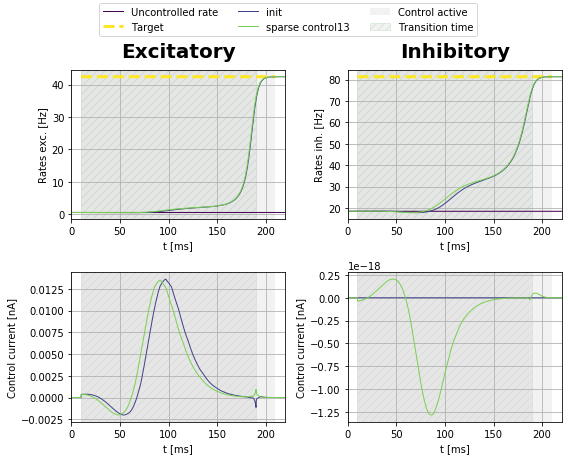

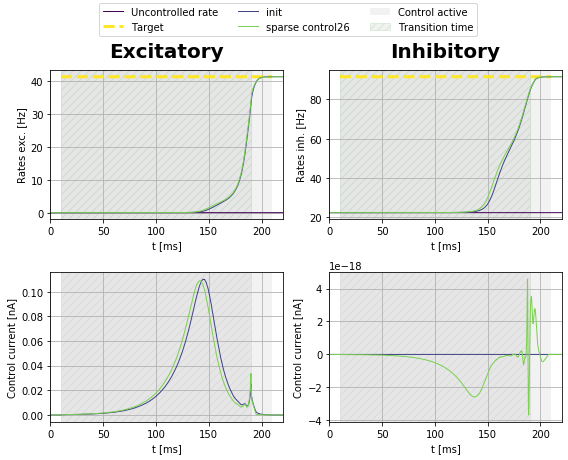

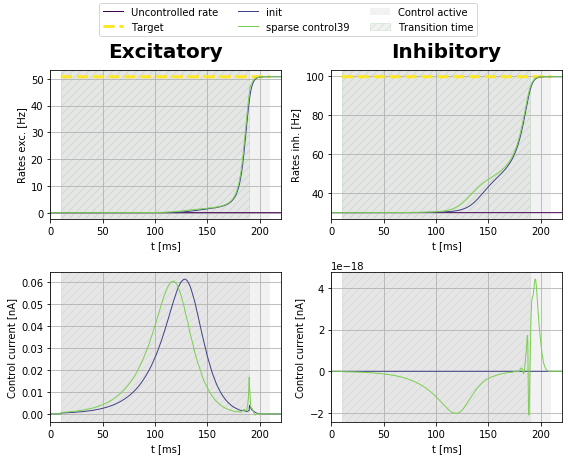

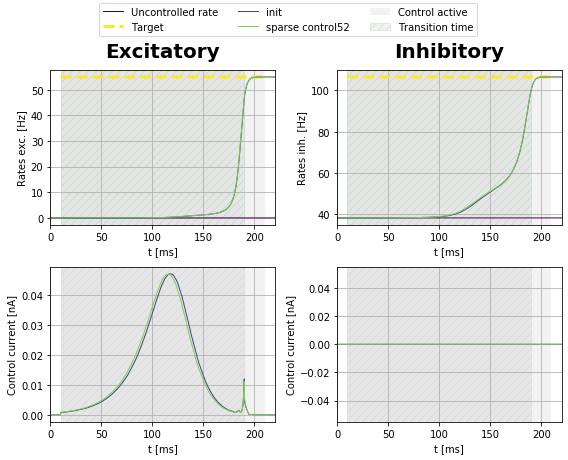

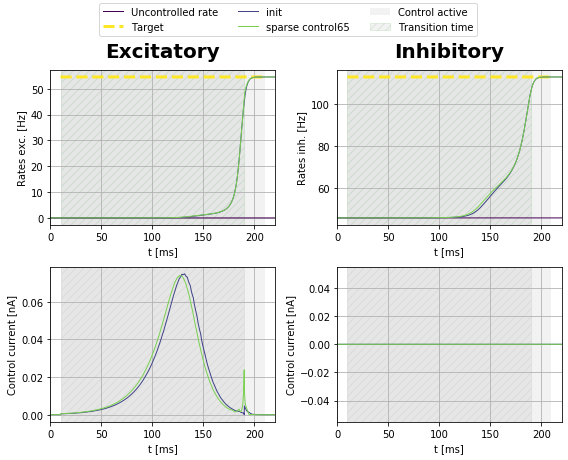

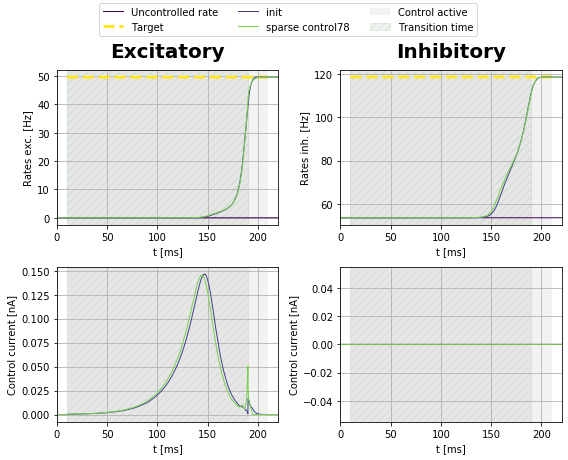

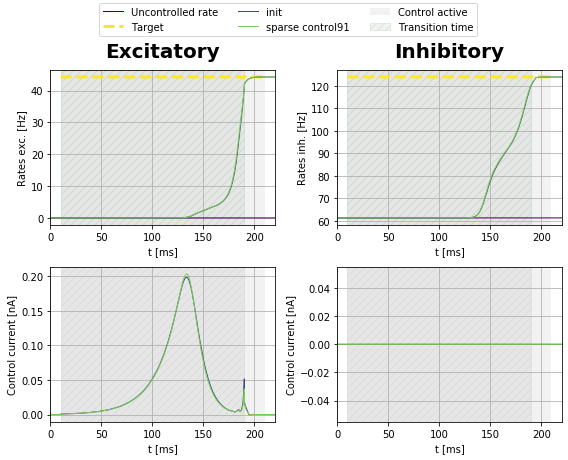

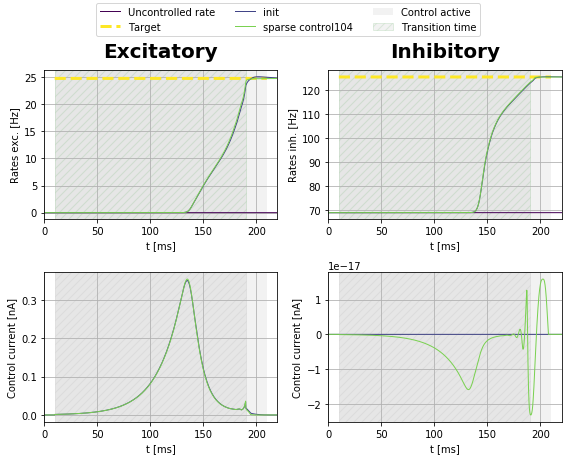

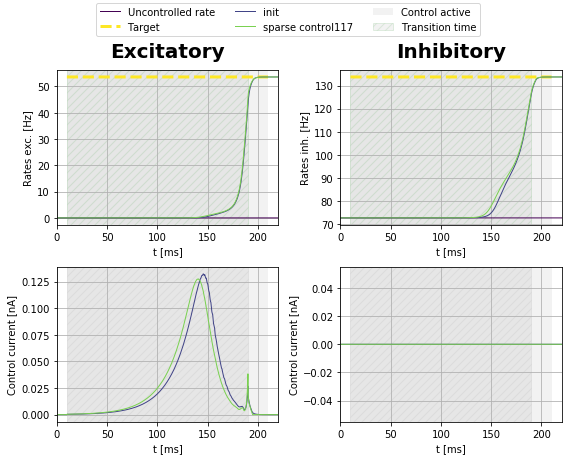

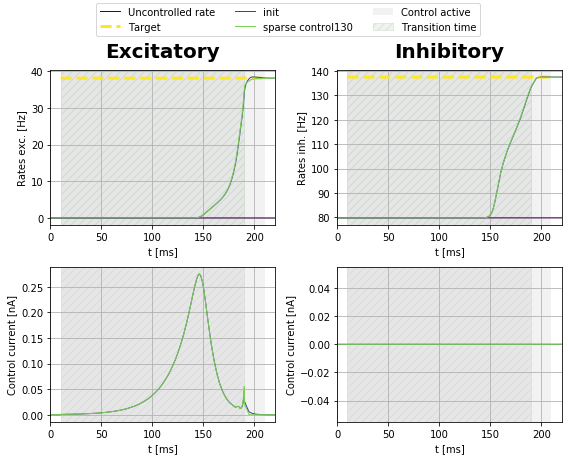

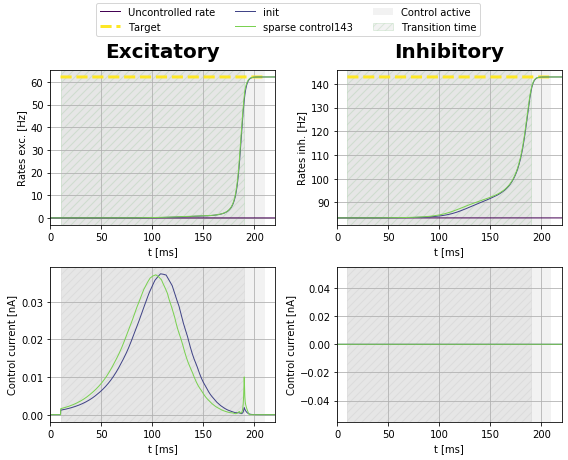

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6146.876597087042
set cost params:  1.0 0.0 6146.876597087042
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5899.391662858791
Gradient descend method:  None
RUN  1 , total integrated cost =  5899.365221692125
RUN  2 , total integrated cost =  5899.365185699566
RUN  3 , total integrated cost =  5899.365185685429
RUN  4 , total integrated cost =  5899.365185685419
RUN  5 , total integrated cost =  5899.365185685417


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  5899.365185685417
Control only changes marginally.
RUN  6 , total integrated cost =  5899.365185685417
Improved over  6  iterations in  1.4153983999999582  seconds by  0.0004488119265175783  percent.
Problem in initial value trasfer:  Vmean_exc -56.626781952774756 -56.62678830368794
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  47591.73291105471
set cost params:  1.0 0.0 47591.73291105471
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17550.41976896361
Gradient descend method:  None
RUN  1 , total integrated cost =  17550.419768963606


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  17550.419768963606
Control only changes marginally.
RUN  2 , total integrated cost =  17550.419768963606
Improved over  2  iterations in  0.5871870000000854  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.69063929540859 -56.69064014323211
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  6196.127875641727
set cost params:  1.0 0.0 6196.127875641727
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17065.999390351702
Gradient descend method:  None
RUN  1 , total integrated cost =  17065.999368414807
RUN  2 , total integrated cost =  17065.99935754455
RUN  3 , total integrated cost =  17065.99935556869
RUN  4 , total integrated cost =  17065.999355230157
RUN  5 , total integrated cost =  17065.99935496896
RUN  6 , total integrated cost =  17065.99935476735
RUN  7 , total integrated cost =  17065.999354688265
RUN  8 , total integrated cost =  17065.999354685435
R

...

RUN  4 , total integrated cost =  5901.446672112559
Control only changes marginally.
RUN  4 , total integrated cost =  5901.446672112559
Improved over  4  iterations in  1.0006099999995968  seconds by  1.1084466677857563e-12  percent.
Problem in initial value trasfer:  Vmean_exc -56.626781852737444 -56.62678820461091
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  8707.952353665609
set cost params:  1.0 0.0 8707.9523536

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28712.244585454297
Control only changes marginally.
RUN  1 , total integrated cost =  28712.244585454297
Improved over  1  iterations in  0.2825573999998596  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408233363243 -56.704082387958366
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 3
[[False, False], [True, False], [True, False], [True, False], [True, False], [True, False], [True, True], [True, True], [True, False], [False, False], [True, False], [True, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  6149.0586218547
set cost params:  1.0 0.0 6149.0586218547
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.446747042094
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5901.446747042094
Control only changes marginally.
RUN  1 , total integrated cost =  5901.446747042094
Improved over  1  iterations in  0.29924469999969006  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.626781852737444 -56.62678820461091
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  36.45887933625783
Gradient descend method:  None
RUN  1 , total integrated cost =  1.0504206365407158
RUN  2 , total integrated cost =  1.0413139502109756
RUN  3 , total integrated cost =  1.0382182447233304
RUN  4 , total integrated cost =  1.0368269049575551
RUN  5 , total integrated cost =  1.0358286881166814
RUN  6 , total integrated cost =  1.0350790014219005
RUN  7 , total integrated cost =  1.034396961892317
RUN  8 , total integrated cost =  1.0337973707852115
RUN  9 , total integrated cost =  1.0331211674254281
RUN  10 , total integrated cost =  1.0325383083578688
RUN  11 , total integrated cost =  1.0319582137484296
RUN  12 , total integrated cost =  1.0314297900598677
RUN  13 , total integrated cost =  1.0308433434342121
RUN  14 , total integrated cost =  1.03029162887138
RUN  15 , total integrated cost =  1.0296962055115941
RU

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  76 , total integrated cost =  1.0072925347343198
Improved over  76  iterations in  3.382618800000273  seconds by  97.2371818523435  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761862728577 -56.627618662529486
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33.23780522195511
Gradient descend method:  None
RUN  1 , total integrated cost =  0.37558216613877904
RUN  2 , total integrated cost =  0.3753456668790649
RUN  3 , total integrated cost =  0.37524790817714404
RUN  4 , total integrated cost =  0.37516326029815517
RUN  5 , total integrated cost =  0.375118865773297
RUN  6 , total integrated cost =  0.3750396051026939
RUN  7 , total integrated cost =  0.37498889550147196
RUN  8 , total integrated cost =  0.3741611816132443
RUN  9 , total integrated cost =  0.37411509691319833
RUN  10 , total integrated cost =  0.3740845995885761

ERROR:root:Problem in initial value trasfer


State only changes marginally.
State only changes marginally.
RUN  190 , total integrated cost =  0.3726622387203162
State only changes marginally.
Control only changes marginally.
RUN  192 , total integrated cost =  0.3726622387203161
Improved over  192  iterations in  7.991254900000058  seconds by  98.87880010057296  percent.
Problem in initial value trasfer:  Vmean_exc -56.69066581748716 -56.69066579564927
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34.658272698843525
Gradient descend method:  None
RUN  1 , total integrated cost =  2.918978714364894
RUN  2 , total integrated cost =  2.9057690033062538
RUN  3 , total integrated cost =  2.894031074132455
RUN  4 , total integrated cost =  2.880495075260373
RUN  5 , total integrated cost =  2.869509900813305
RUN  6 , total integrated cost =  2.8598778723296356
RUN  7 , total integrated cost =  2.8517268395539674
RUN  8 , total in

RUN  300 , total integrated cost =  1.4656958856427902
RUN  400 , total integrated cost =  1.4654692756652445
RUN  500 , total integrated cost =  1.4654509148510007
RUN  600 , total integrated cost =  1.4650381782802282
RUN  700 , total integrated cost =  1.46502111824685
RUN  800 , total integrated cost =  1.4647227001328913
RUN  900 , total integrated cost =  1.4647197418249815
RUN  1000 , total integrated cost =  1.4647142917435043
Control only changes marginally.
RUN  1090 , total integrated cost =  1.4643683664084504
Improved over  1090  iterations in  44.17481429999998  seconds by  96.3881496596303  percent.
-------  65 0.5500000000000003 0.6250000000000003
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  39.45689747847873
Gradient descend method:  None
RUN  1 , total integrated cost =  2.137380380819732
RUN  2 , total integrated cost =  2.1325182174054786
RUN  3 , total integrated cost =  2.1320754074922377
RUN  4 , total inte

RUN  300 , total integrated cost =  5.004019931832956
RUN  400 , total integrated cost =  5.003155340364137
RUN  500 , total integrated cost =  5.002365318228116
RUN  600 , total integrated cost =  5.001786786323039
RUN  700 , total integrated cost =  5.001121385219211
RUN  800 , total integrated cost =  5.000346335420643
RUN  900 , total integrated cost =  4.99976843404192
RUN  1000 , total integrated cost =  4.999230731196221
RUN  1100 , total integrated cost =  4.998574507253748
RUN  1200 , total integrated cost =  4.998048398807906
RUN  1300 , total integrated cost =  4.99802775647456
RUN  1400 , total integrated cost =  4.997673208092496
Control only changes marginally.
RUN  1454 , total integrated cost =  4.997622728202929
Improved over  1454  iterations in  63.86657789999981  seconds by  49.429740145881915  percent.
-------  104 0.4250000000000001 0.7750000000000005
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8.4732618602

RUN  30 , total integrated cost =  6.577646164207803
RUN  40 , total integrated cost =  6.577081243256882
RUN  50 , total integrated cost =  6.576793414852932
RUN  60 , total integrated cost =  6.576457120975207
RUN  70 , total integrated cost =  6.576231324365396
RUN  80 , total integrated cost =  6.576054645684676
RUN  90 , total integrated cost =  6.575884949112536
RUN  100 , total integrated cost =  6.575816592707748
RUN  110 , total integrated cost =  6.575738296308268
RUN  120 , total integrated cost =  6.575664427903586
RUN  130 , total integrated cost =  6.575590326464268
RUN  140 , total integrated cost =  6.575529564909231
RUN  150 , total integrated cost =  6.5754415246278946
RUN  160 , total integrated cost =  6.575343223498506
RUN  170 , total integrated cost =  6.575268963936279
RUN  180 , total integrated cost =  6.575201083802528
RUN  190 , total integrated cost =  6.575121689883673
RUN  200 , total integrated cost =  6.575046869976154
RUN  300 , total integrated cost =

In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.0072925347343198
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  1.0072925347343198
Control only changes marginally.
RUN  1 , total integrated cost =  1.0072925347343198
Improved over  1  iterations in  0.09639680000009321  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761862728577 -56.627618662529486
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.3726622387203161
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.3726622387203161
Control only changes marginally.
RUN  1 , total integrated cost =  0.3726622387203161
Improved over  1  iterations in  0.09635070000013002  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.69066581748716 -56.69066579564927
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.7642539913905826
Gradient descend method:  None
RUN  1 , total integrated cost =  2.7642539913905826
Control only changes marginally.
RUN  1 , total integrated cost =  2.7642539913905826
Improved over  1  iterations in  0.09748110000009547  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000000002
no convergence
set cost params:  1.0 0.0 1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.7472544963958674
Gradient descend method:  None
RUN  1 , total integrated cost =  1.74725449

converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.6750000000000004
converged for  78
-------  91 0.5000000000000002 0.7250000000000004
converged for  91
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
converged for  117
-------  130 0.47500000000000014 0.8500000000000005
converged for  130
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 14
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
full convergence


In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
